- 通过原子数估计覆盖区域的长轴：$L = \sqrt{N_{\mathrm{beam}}}\,a$，其中，$N_{\mathrm{beam}}$ 为光束覆盖原子数，$a$ 为晶格间距。短轴尽可能小，取为$s = 6 \mu m$

- 利用光强反推电场强度
$$
E_0 = \sqrt{\frac{2I}{c\,\varepsilon_0}}
    = \frac{1}{\sqrt{Ls}}\sqrt{\frac{2\,P_{420,\mathrm{eff}}}{c\,\varepsilon_0}}.
$$
- 利用420激光的跃迁路径 $\Omega_{420} = {|d_{\mathrm{eg}}|\,E_0}/{\hbar}$

`our` 路径：$|5S_{1/2},m_J=-\tfrac12\rangle \xrightarrow{\sigma^-} |6P_{3/2},m_J=-\tfrac32\rangle$。

$$
\boxed{
\Omega_{420}
= \frac{|d_{\mathrm{au}}(5S_{1/2}\!\to\!6P_{3/2};\,\sigma^-)|\,e\,a_0}{\hbar\,\sqrt{Ls}}
\sqrt{\frac{2\,P_{420}(1-\eta_{\mathrm{loss}})}{c\,\varepsilon_0}},
\qquad
L=\sqrt{N_{\mathrm{beam}}}\,a.
}
$$

In [1]:
import sys
from pathlib import Path

import numpy as np

HERE = Path.cwd().resolve()
REPO = HERE.parents[1] if HERE.name == "notebooks" else HERE
sys.path.insert(0, str(REPO / "src"))

from ryd_gate.physics import our_laser_rabis

MHz = 2 * np.pi * 1e6

# same defaults as scripts/error_budget_sweep.py
P420_W, P1013_W = 0.3, 100.0
OPTICS_PATH_LOSS = 0.90
N_BEAM_ATOMS = 400
RYD_LEVEL = 70
A_UM = 7.0

beam_side_um = float(np.sqrt(N_BEAM_ATOMS) * A_UM)
s = 6.0
omega_420, omega_1013 = our_laser_rabis(
    P420_W * (1 - OPTICS_PATH_LOSS),
    P1013_W * (1 - OPTICS_PATH_LOSS),
    beam_area = beam_side_um * s,
    ryd_level=RYD_LEVEL,
)

print(f"a = {A_UM} µm,  L_beam = {beam_side_um:.1f} µm")
print(f"Ω_420/2π  = {omega_420 / MHz:.1f} MHz   (our cal: 491 MHz)")
print(f"Ω_1013/2π = {omega_1013 / MHz:.1f} MHz   (our cal: 185 MHz)")

a = 7.0 µm,  L_beam = 140.0 µm
Ω_420/2π  = 567.8 MHz   (our cal: 491 MHz)
Ω_1013/2π = 199.9 MHz   (our cal: 185 MHz)


In [2]:
# explain why 420 nm laser is extremely strong

from arc import Rubidium87

_atom = Rubidium87()
RYD_LEVEL = 70

# Ω/E0 (rad/s per V/m); e0=1 for comparison. Matches our_laser_rabis / physical_models "our".
# 420 nm: |5S_1/2, mJ=-1/2> --σ⁻--> |6P_3/2, mJ=-3/2>
d_420 = float(_atom.getRabiFrequency2(5, 0, 0.5, -0.5, 6, 1, 1.5, -1, 1.0))

# 1013 nm: |6P_3/2, mJ=-1/2> --σ⁺--> |70S_1/2, mJ=+1/2>
d_1013 = float(_atom.getRabiFrequency2(6, 1, 1.5, -0.5, RYD_LEVEL, 0, 0.5, 1, 1.0))

print(f"|d_420|/E0  = {d_420:.3e} rad/s per V/m")
print(f"|d_1013|/E0 = {d_1013:.3e} rad/s per V/m")
print(f"ratio |d_420|/|d_1013| = {d_420 / d_1013:.2f}")

|d_420|/E0  = 2.175e+04 rad/s per V/m
|d_1013|/E0 = 4.193e+02 rad/s per V/m
ratio |d_420|/|d_1013| = 51.86


In [3]:
t_sweep = 2.5 * 1e-6
Delta_e = 2*np.pi* 9.1e9
Omega = omega_420*omega_1013/(2*Delta_e)          # rad/s
print(Omega)
delta_start  = - 2*np.pi*10*1e6
delta_end  =  2*np.pi*10*1e6
# Effectively global Rabi
def omega_half_t(t):
    ramp_frac = 0.09
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)
    def smoothstep5(u):
        u = np.clip(u, 0.0, 1.0)
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5
    if s < ramp_frac:
        env = smoothstep5(s / ramp_frac)
    elif s > 1.0 - ramp_frac:
        env = smoothstep5((1.0 - s) / ramp_frac)
    else:
        env = 1.0
    return 0.5 * Omega * env
# 全局 Rydberg 失谐：平滑往返扫频 -10 MHz -> +10 MHz -> -10 MHz
def delta_t(t):
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)
    delta_mid = 0.5 * (delta_start + delta_end)
    delta_amp = 0.5 * (delta_end - delta_start)
    return delta_mid - delta_amp * np.cos(2.0 * np.pi * s)

import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
# 2. 自定义 sweep：global Delta(t) 和 local address shift 分开输入
protocol = rg.SweepProtocol(
    t_gate=t_sweep,
    omega_half_fn=omega_half_t,
    delta_fn=delta_t,
    n_steps=120,
)

system = (
    rg.RydbergSystem
    .set_atom_level("1r")
    .set_atom_geom(
        Register.rectangle(2, 2, spacing_um=A_UM),
        interaction=InteractionSpec(C6=2 * np.pi * 874e9, mode="nn"),       # 近邻 VdW；TN 勿用默认 all
    )
    .set_protocol(protocol)
)

39180390.13802586


T = 2.500 us
return prob  = 0.999822
phase (rad)  = -0.446001
phase/pi     = -0.141966


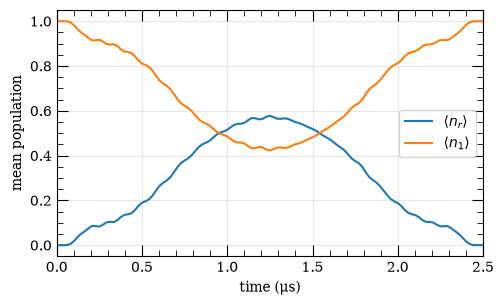

intermediate-state scattering estimate
Gamma_e = 9.033424e+06 s^-1
mean p_sc  = 1.843018e-02
max  p_sc  = 1.843018e-02
420 leg mean contribution  = 1.764000e-02 (95.713%)
1013 leg mean contribution = 7.901862e-04 (4.287%)
p_sc_i by site layout:
[[0.018 0.018]
 [0.018 0.018]]


In [4]:
# 3a. 精确后端：全演化轨迹 + 终点返回概率/动力学相位。
import matplotlib.pyplot as plt

method = "exact"
t_gate = system.protocol.t_gate
n_eval_steps = getattr(system.protocol, "n_steps", None) or 200
t_eval = np.linspace(0.0, t_gate, n_eval_steps + 1)

res = rg.simulate(system, [], "all_ground", backend="exact_dense", t_eval=t_eval)
times = np.asarray(res.times)
states = np.asarray(res.states)

psi0 = system.ground_state()
overlap = np.vdot(psi0, res.psi_final)
exact_return = float(abs(overlap) ** 2)
exact_phase = float(np.angle(overlap))

n1_sites = np.asarray([
    [system.expectation(f"n_1_{i}", psi) for i in range(system.N)]
    for psi in states
])
nr_sites = np.asarray([
    [system.expectation(f"n_r_{i}", psi) for i in range(system.N)]
    for psi in states
])
n1_mean = np.mean(n1_sites, axis=1)
nr_mean = np.mean(nr_sites, axis=1)

print(f"T = {t_gate * 1e6:.3f} us")
print(f"return prob  = {exact_return:.6f}")
print(f"phase (rad)  = {exact_phase:+.6f}")
print(f"phase/pi     = {exact_phase / np.pi:+.6f}")

fig, ax = plt.subplots(figsize=(5.5, 3.2))
t_us = times * 1e6
ax.plot(t_us, nr_mean, label=r"$\langle n_r \rangle$")
ax.plot(t_us, n1_mean, label=r"$\langle n_1 \rangle$")
ax.set_xlabel("time (μs)")
ax.set_ylabel("mean population")
ax.set_xlim(0.0, t_gate * 1e6)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

# 中间态散射的微扰积分估计：p_sc_i = Gamma_e * int(..., t) dt。
trapz = getattr(np, "trapezoid", None) or np.trapz
Gamma_e = 1.0 / 110.7e-9

omega_eff_for_env = omega_420 * omega_1013 / (2.0 * Delta_e)
env_420 = np.asarray([
    2.0 * system.protocol.omega_half_at(t) / omega_eff_for_env
    for t in times
], dtype=float)
env_420 = np.clip(env_420, 0.0, 1.0)
omega_420_t = omega_420 * env_420

leg_420 = (4.0 / 3.0) * (omega_420_t[:, None] / (2.0 * Delta_e)) ** 2 * n1_sites
leg_1013 = (omega_1013 / (2.0 * Delta_e)) ** 2 * nr_sites
p_sc_420_i = Gamma_e * trapz(leg_420, times, axis=0)
p_sc_1013_i = Gamma_e * trapz(leg_1013, times, axis=0)
p_sc_i = p_sc_420_i + p_sc_1013_i

p_sc_mean = float(np.mean(p_sc_i))
p_sc_max = float(np.max(p_sc_i))
p_sc_420_mean = float(np.mean(p_sc_420_i))
p_sc_1013_mean = float(np.mean(p_sc_1013_i))

print("intermediate-state scattering estimate")
print(f"Gamma_e = {Gamma_e:.6e} s^-1")
print(f"mean p_sc  = {p_sc_mean:.6e}")
print(f"max  p_sc  = {p_sc_max:.6e}")
print(f"420 leg mean contribution  = {p_sc_420_mean:.6e} ({p_sc_420_mean / p_sc_mean:.3%})")
print(f"1013 leg mean contribution = {p_sc_1013_mean:.6e} ({p_sc_1013_mean / p_sc_mean:.3%})")

side = int(round(np.sqrt(system.N)))
if side * side == system.N:
    print("p_sc_i by site layout:")
    print(np.array2string(p_sc_i.reshape(side, side), precision=3, suppress_small=False))
else:
    print("p_sc_i by site:")
    print(np.array2string(p_sc_i, precision=3, suppress_small=False))


In [5]:
# Generate, cache, or load three-parameter error-budget scan results.
# Channels:
#   mid scattering: perturbative intermediate-state scattering estimate
#   Ryd scattering: Gamma_r * int n_r_i(t) dt
#   adiabatic violation: final residual Rydberg population n_r_i(T)
#   total: sum of the three per-site channels

# 30 samples per axis: 30^3 = 27000 exact-evolution scan points.
P420_grid = np.linspace(0.10, 6, 30)  # W, nominal power before path loss
t_sweep_grid = np.linspace(1.5, 4.0, 30) * 1e-6
Delta_e_grid = 2.0 * np.pi * np.linspace(10.0, 120.0, 30) * 1e9

scan_n_steps = 80
scan_n_eval_steps = scan_n_steps
scan_backend = "exact_dense"
trapz = getattr(np, "trapezoid", None) or np.trapz
Gamma_e = 1.0 / 110.7e-9
Gamma_r = 1.0 / 151.55e-6

scan_result_path = REPO / "results" / "error_budget_3param_scan.npz"
force_recompute_scan = False

scan_required_cache_keys = (
    "P420_grid",
    "t_sweep_grid",
    "Delta_e_grid",
    "scan_p_mid_i",
    "scan_p_mid_420_i",
    "scan_p_mid_1013_i",
    "scan_p_ryd_i",
    "scan_p_ad_i",
    "scan_p_total_i",
    "scan_return_prob",
    "scan_omega_eff_mhz",
)

def scan_cache_is_usable(path):
    if force_recompute_scan or not path.exists():
        return False
    try:
        with np.load(path) as cache:
            if not all(key in cache.files for key in scan_required_cache_keys):
                return False
            grids_match = (
                np.allclose(cache["P420_grid"], P420_grid)
                and np.allclose(cache["t_sweep_grid"], t_sweep_grid)
                and np.allclose(cache["Delta_e_grid"], Delta_e_grid)
            )
            expected_shape = (len(P420_grid), len(t_sweep_grid), len(Delta_e_grid))
            arrays_match = cache["scan_p_mid_i"].shape[:3] == expected_shape
            return bool(grids_match and arrays_match)
    except Exception as exc:
        print(f"ignoring unreadable scan cache {path}: {exc}")
        return False

def load_scan_cache(path):
    with np.load(path) as cache:
        loaded = {key: cache[key] for key in cache.files}
    print(f"loaded cached scan arrays from {path}")
    return loaded

loaded_cache = load_scan_cache(scan_result_path) if scan_cache_is_usable(scan_result_path) else None

if loaded_cache is not None:
    P420_grid = loaded_cache["P420_grid"]
    t_sweep_grid = loaded_cache["t_sweep_grid"]
    Delta_e_grid = loaded_cache["Delta_e_grid"]
    scan_p_mid_i = loaded_cache["scan_p_mid_i"]
    scan_p_mid_420_i = loaded_cache["scan_p_mid_420_i"]
    scan_p_mid_1013_i = loaded_cache["scan_p_mid_1013_i"]
    scan_p_ryd_i = loaded_cache["scan_p_ryd_i"]
    scan_p_ad_i = loaded_cache["scan_p_ad_i"]
    scan_p_total_i = loaded_cache["scan_p_total_i"]
    scan_return_prob = loaded_cache["scan_return_prob"]
    scan_omega_eff_mhz = loaded_cache["scan_omega_eff_mhz"]
else:
    print(f"no usable cached scan found at {scan_result_path}; running full scan")

    scan_beam_side_um = float(np.sqrt(N_BEAM_ATOMS) * A_UM)
    scan_beam_area_um2 = scan_beam_side_um * s
    scan_geometry = Register.rectangle(2, 2, spacing_um=A_UM)
    scan_base_system = (
        rg.RydbergSystem
        .set_atom_level("1r")
        .set_atom_geom(scan_geometry, interaction=InteractionSpec(C6=2.0 * np.pi * 874e9, mode="nn"))
        .build()
    )

    def scan_smoothstep5(u):
        u = np.clip(u, 0.0, 1.0)
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

    def scan_laser_rabis(p420_w):
        return our_laser_rabis(
            p420_w * (1.0 - OPTICS_PATH_LOSS),
            P1013_W * (1.0 - OPTICS_PATH_LOSS),
            beam_area=scan_beam_area_um2,
            ryd_level=RYD_LEVEL,
        )

    def make_scan_schedule(omega_eff_val, t_sweep_val):
        ramp_frac = 0.09

        def env_fn(t):
            ss = np.clip(np.asarray(t, dtype=float) / max(t_sweep_val, np.finfo(float).eps), 0.0, 1.0)
            rise = scan_smoothstep5(ss / ramp_frac)
            fall = scan_smoothstep5((1.0 - ss) / ramp_frac)
            return np.where(ss < ramp_frac, rise, np.where(ss > 1.0 - ramp_frac, fall, 1.0))

        def omega_half_fn(t):
            return float(0.5 * omega_eff_val * env_fn(t))

        def delta_fn(t):
            ss = float(np.clip(t / max(t_sweep_val, np.finfo(float).eps), 0.0, 1.0))
            delta_mid = 0.5 * (delta_start + delta_end)
            delta_amp = 0.5 * (delta_end - delta_start)
            return float(delta_mid - delta_amp * np.cos(2.0 * np.pi * ss))

        protocol = rg.SweepProtocol(
            t_gate=t_sweep_val,
            omega_half_fn=omega_half_fn,
            delta_fn=delta_fn,
            n_steps=scan_n_steps,
        )
        return protocol, env_fn

    def compute_error_scan_point(p420_w, t_sweep_val, delta_e_val):
        o420, o1013 = scan_laser_rabis(float(p420_w))
        omega_eff_val = o420 * o1013 / (2.0 * delta_e_val)
        protocol, env_fn = make_scan_schedule(omega_eff_val, float(t_sweep_val))
        scan_system = scan_base_system.with_protocol(protocol)
        t_eval_scan = np.linspace(0.0, float(t_sweep_val), scan_n_eval_steps + 1)

        res_scan = rg.simulate(
            scan_system,
            [],
            "all_ground",
            backend=scan_backend,
            t_eval=t_eval_scan,
        )
        states_scan = np.asarray(res_scan.states)
        nr_scan = np.asarray([
            [scan_system.expectation(f"n_r_{i}", psi) for i in range(scan_system.N)]
            for psi in states_scan
        ])
        n1_scan = np.asarray([
            [scan_system.expectation(f"n_1_{i}", psi) for i in range(scan_system.N)]
            for psi in states_scan
        ])

        env = np.asarray(env_fn(t_eval_scan), dtype=float)
        leg_420 = (4.0 / 3.0) * (o420 * env[:, None] / (2.0 * delta_e_val)) ** 2 * n1_scan
        leg_1013 = (o1013 / (2.0 * delta_e_val)) ** 2 * nr_scan
        p_mid_420_i = Gamma_e * trapz(leg_420, t_eval_scan, axis=0)
        p_mid_1013_i = Gamma_e * trapz(leg_1013, t_eval_scan, axis=0)
        p_mid_i = p_mid_420_i + p_mid_1013_i
        p_ryd_i = Gamma_r * trapz(nr_scan, t_eval_scan, axis=0)
        p_ad_i = np.asarray(nr_scan[-1, :], dtype=float)
        p_total_i = p_mid_i + p_ryd_i + p_ad_i

        overlap = np.vdot(scan_system.ground_state(), res_scan.psi_final)
        return {
            "p_mid_i": p_mid_i,
            "p_mid_420_i": p_mid_420_i,
            "p_mid_1013_i": p_mid_1013_i,
            "p_ryd_i": p_ryd_i,
            "p_ad_i": p_ad_i,
            "p_total_i": p_total_i,
            "return_prob": float(abs(overlap) ** 2),
            "omega_eff": float(omega_eff_val),
        }

    scan_shape = (len(P420_grid), len(t_sweep_grid), len(Delta_e_grid))
    scan_p_mid_i = np.full(scan_shape + (scan_base_system.N,), np.nan, dtype=float)
    scan_p_mid_420_i = np.full_like(scan_p_mid_i, np.nan)
    scan_p_mid_1013_i = np.full_like(scan_p_mid_i, np.nan)
    scan_p_ryd_i = np.full_like(scan_p_mid_i, np.nan)
    scan_p_ad_i = np.full_like(scan_p_mid_i, np.nan)
    scan_p_total_i = np.full_like(scan_p_mid_i, np.nan)
    scan_return_prob = np.full(scan_shape, np.nan, dtype=float)
    scan_omega_eff_mhz = np.full(scan_shape, np.nan, dtype=float)

    total_jobs = int(np.prod(scan_shape))
    scan_progress_stride = max(1, total_jobs // 100)
    job = 0
    for ip, p420_val in enumerate(P420_grid):
        for it, t_val in enumerate(t_sweep_grid):
            for idel, de_val in enumerate(Delta_e_grid):
                job += 1
                out = compute_error_scan_point(p420_val, t_val, de_val)
                scan_p_mid_i[ip, it, idel, :] = out["p_mid_i"]
                scan_p_mid_420_i[ip, it, idel, :] = out["p_mid_420_i"]
                scan_p_mid_1013_i[ip, it, idel, :] = out["p_mid_1013_i"]
                scan_p_ryd_i[ip, it, idel, :] = out["p_ryd_i"]
                scan_p_ad_i[ip, it, idel, :] = out["p_ad_i"]
                scan_p_total_i[ip, it, idel, :] = out["p_total_i"]
                scan_return_prob[ip, it, idel] = out["return_prob"]
                scan_omega_eff_mhz[ip, it, idel] = out["omega_eff"] / MHz
                if job == 1 or job == total_jobs or job % scan_progress_stride == 0:
                    print(
                        f"[{job:05d}/{total_jobs}] "
                        f"P420={p420_val:.3f} W, "
                        f"T={t_val * 1e6:.2f} us, "
                        f"Delta_e/2pi={de_val / (2.0 * np.pi * 1e9):.2f} GHz, "
                        f"mid={np.mean(out['p_mid_i']):.3e}, "
                        f"ryd={np.mean(out['p_ryd_i']):.3e}, "
                        f"ad={np.mean(out['p_ad_i']):.3e}, "
                        f"total={np.mean(out['p_total_i']):.3e}"
                    )

    scan_result_path.parent.mkdir(exist_ok=True)
    np.savez_compressed(
        scan_result_path,
        P420_grid=P420_grid,
        t_sweep_grid=t_sweep_grid,
        Delta_e_grid=Delta_e_grid,
        scan_p_mid_i=scan_p_mid_i,
        scan_p_mid_420_i=scan_p_mid_420_i,
        scan_p_mid_1013_i=scan_p_mid_1013_i,
        scan_p_ryd_i=scan_p_ryd_i,
        scan_p_ad_i=scan_p_ad_i,
        scan_p_total_i=scan_p_total_i,
        scan_return_prob=scan_return_prob,
        scan_omega_eff_mhz=scan_omega_eff_mhz,
        Gamma_e=Gamma_e,
        Gamma_r=Gamma_r,
        P1013_W=P1013_W,
        OPTICS_PATH_LOSS=OPTICS_PATH_LOSS,
        A_UM=A_UM,
        scan_n_steps=scan_n_steps,
        scan_n_eval_steps=scan_n_eval_steps,
        scan_backend=scan_backend,
    )
    print(f"saved scan arrays to {scan_result_path}")

scan_p_mid_mean = np.mean(scan_p_mid_i, axis=-1)
scan_p_mid_max = np.max(scan_p_mid_i, axis=-1)
scan_p_mid_420_mean = np.mean(scan_p_mid_420_i, axis=-1)
scan_p_mid_1013_mean = np.mean(scan_p_mid_1013_i, axis=-1)
scan_p_ryd_mean = np.mean(scan_p_ryd_i, axis=-1)
scan_p_ad_mean = np.mean(scan_p_ad_i, axis=-1)
scan_p_total_mean = np.mean(scan_p_total_i, axis=-1)

# Backward-compatible aliases for earlier cells/notebook exploration.
scan_p_sc_i = scan_p_mid_i
scan_p_sc_420_i = scan_p_mid_420_i
scan_p_sc_1013_i = scan_p_mid_1013_i
scan_p_sc_mean = scan_p_mid_mean
scan_p_sc_max = scan_p_mid_max
scan_p_sc_420_mean = scan_p_mid_420_mean
scan_p_sc_1013_mean = scan_p_mid_1013_mean

channel_means = {
    "mid": scan_p_mid_mean,
    "ryd": scan_p_ryd_mean,
    "adiabatic": scan_p_ad_mean,
    "total": scan_p_total_mean,
}
channel_min_idx = {name: np.unravel_index(np.nanargmin(vals), vals.shape) for name, vals in channel_means.items()}
channel_max_idx = {name: np.unravel_index(np.nanargmax(vals), vals.shape) for name, vals in channel_means.items()}
min_idx = channel_min_idx["mid"]
max_idx = channel_max_idx["mid"]
total_min_idx = channel_min_idx["total"]
total_max_idx = channel_max_idx["total"]

def describe_scan_idx(idx):
    ip, it, idel = idx
    return (
        f"P420={P420_grid[ip]:.3f} W, "
        f"T={t_sweep_grid[it] * 1e6:.2f} us, "
        f"Delta_e/2pi={Delta_e_grid[idel] / (2.0 * np.pi * 1e9):.2f} GHz"
    )

p0_idx = int(np.argmin(np.abs(P420_grid - P420_W)))
t0_idx = int(np.argmin(np.abs(t_sweep_grid - t_sweep)))
d0_idx = int(np.argmin(np.abs(Delta_e_grid - Delta_e)))
nominal_idx = (p0_idx, t0_idx, d0_idx)

print("scan summary")
for name, vals in channel_means.items():
    lo = channel_min_idx[name]
    hi = channel_max_idx[name]
    print(f"{name:9s} min = {vals[lo]:.6e} at {describe_scan_idx(lo)}")
    print(f"{name:9s} max = {vals[hi]:.6e} at {describe_scan_idx(hi)}")
print("nearest nominal grid point:", describe_scan_idx(nominal_idx))
print(f"nominal-grid mid scattering = {scan_p_mid_mean[nominal_idx]:.6e}")
print(f"nominal-grid Ryd scattering = {scan_p_ryd_mean[nominal_idx]:.6e}")
print(f"nominal-grid adiabatic violation = {scan_p_ad_mean[nominal_idx]:.6e}")
print(f"nominal-grid total = {scan_p_total_mean[nominal_idx]:.6e}")
print(
    "nominal-grid 420 fraction of mid scattering = "
    f"{scan_p_mid_420_mean[nominal_idx] / scan_p_mid_mean[nominal_idx]:.3%}"
)


no usable cached scan found at /home/chance/Ryd-gate-modeling/results/error_budget_3param_scan.npz; running full scan
[00001/27000] P420=0.100 W, T=1.50 us, Delta_e/2pi=10.00 GHz, mid=3.385e-03, ryd=2.670e-03, ad=1.406e-02, total=2.011e-02


[00270/27000] P420=0.100 W, T=2.19 us, Delta_e/2pi=120.00 GHz, mid=4.304e-05, ryd=3.678e-04, ad=4.773e-02, total=4.814e-02
[00540/27000] P420=0.100 W, T=2.97 us, Delta_e/2pi=120.00 GHz, mid=5.765e-05, ryd=8.129e-04, ad=8.503e-02, total=8.590e-02
[00810/27000] P420=0.100 W, T=3.74 us, Delta_e/2pi=120.00 GHz, mid=7.283e-05, ryd=9.241e-04, ad=5.213e-02, total=5.313e-02
[01080/27000] P420=0.303 W, T=1.93 us, Delta_e/2pi=120.00 GHz, mid=1.082e-04, ryd=1.115e-03, ad=2.012e-01, total=2.024e-01
[01350/27000] P420=0.303 W, T=2.71 us, Delta_e/2pi=120.00 GHz, mid=1.490e-04, ryd=1.815e-03, ad=1.633e-01, total=1.653e-01
[01620/27000] P420=0.303 W, T=3.48 us, Delta_e/2pi=120.00 GHz, mid=1.831e-04, ryd=3.428e-03, ad=2.899e-01, total=2.935e-01
[01890/27000] P420=0.507 W, T=1.67 us, Delta_e/2pi=120.00 GHz, mid=1.514e-04, ryd=1.268e-03, ad=2.412e-01, total=2.427e-01
[02160/27000] P420=0.507 W, T=2.45 us, Delta_e/2pi=120.00 GHz, mid=2.098e-04, ryd=2.638e-03, ad=2.928e-01, total=2.957e-01
[02430/27000] P4

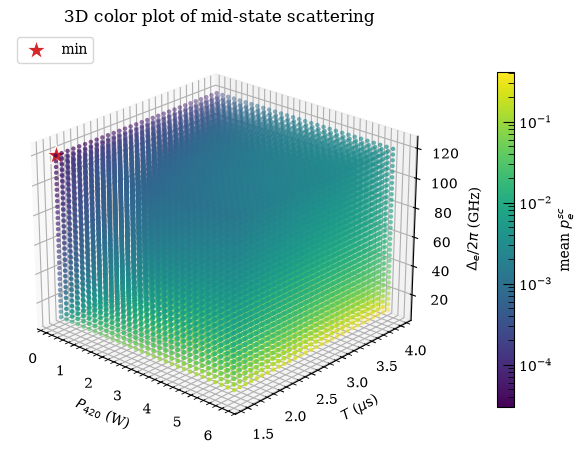

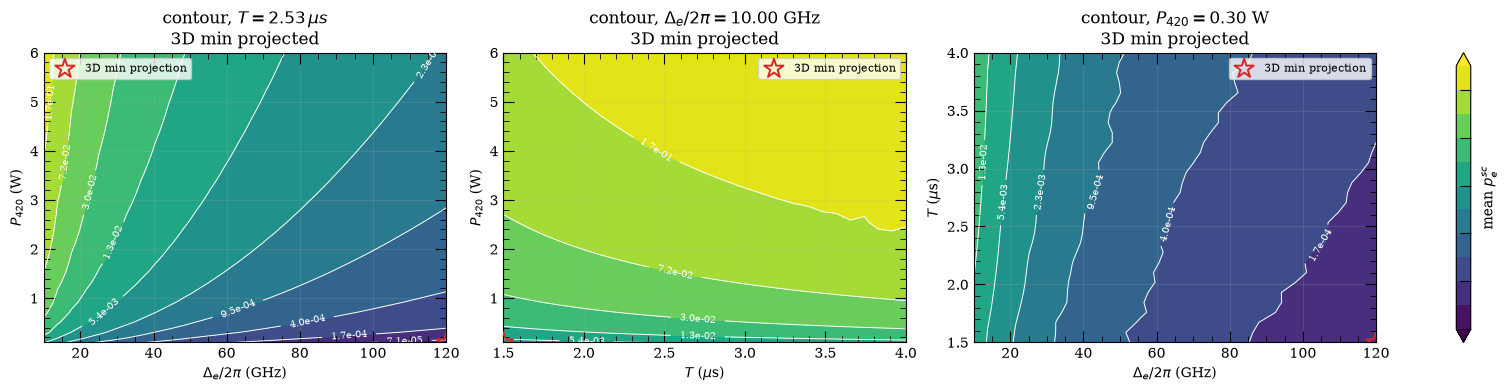

In [6]:
# Mid-state scattering: 3D color plot + contour slices.
from matplotlib.colors import LogNorm

P_mesh, T_mesh_us, De_mesh_ghz = np.meshgrid(
    P420_grid,
    t_sweep_grid * 1e6,
    Delta_e_grid / (2.0 * np.pi * 1e9),
    indexing="ij",
)

def plot_3d_and_contours(scan_values, *, label, title, min_marker=True):
    scan_values = np.asarray(scan_values, dtype=float)
    positive_values = scan_values[np.isfinite(scan_values) & (scan_values > 0.0)]
    if positive_values.size == 0:
        raise ValueError(f"{label} has no positive finite values to plot.")

    use_log_color = positive_values.max() / positive_values.min() > 20.0
    color_norm = LogNorm(vmin=positive_values.min(), vmax=positive_values.max()) if use_log_color else None
    plot_values = np.where(scan_values > 0.0, scan_values, positive_values.min()) if use_log_color else scan_values
    contour_levels = (
        np.geomspace(positive_values.min(), positive_values.max(), 12)
        if use_log_color
        else np.linspace(np.nanmin(scan_values), np.nanmax(scan_values), 12)
    )
    local_min_idx = np.unravel_index(np.nanargmin(scan_values), scan_values.shape)

    fig = plt.figure(figsize=(7.4, 5.8))
    ax = fig.add_subplot(111, projection="3d")
    point_size = 10 if scan_values.size > 5000 else 64
    sc = ax.scatter(
        P_mesh.ravel(),
        T_mesh_us.ravel(),
        De_mesh_ghz.ravel(),
        c=plot_values.ravel(),
        cmap="viridis",
        norm=color_norm,
        s=point_size,
        edgecolor="none" if scan_values.size > 5000 else "k",
        linewidth=0.25,
        depthshade=True,
    )
    if min_marker:
        ax.scatter(
            P420_grid[local_min_idx[0]],
            t_sweep_grid[local_min_idx[1]] * 1e6,
            Delta_e_grid[local_min_idx[2]] / (2.0 * np.pi * 1e9),
            marker="*",
            s=220,
            color="tab:red",
            edgecolor="white",
            linewidth=0.8,
            label="min",
        )
    ax.set_xlabel(r"$P_{420}$ (W)")
    ax.set_ylabel(r"$T$ ($\mu$s)")
    ax.set_zlabel(r"$\Delta_e/2\pi$ (GHz)")
    ax.set_title(title)
    ax.view_init(elev=24, azim=-48)
    if min_marker:
        ax.legend(loc="upper left")
    cbar = fig.colorbar(sc, ax=ax, pad=0.12, shrink=0.75)
    cbar.set_label(label)
    plt.show()

    fig, axs = plt.subplots(1, 3, figsize=(15.0, 3.8), constrained_layout=True)

    def draw_contour(ax, x, y, z, xlabel, ylabel, panel_title, opt_x, opt_y, on_slice):
        cf = ax.contourf(x, y, z, levels=contour_levels, cmap="viridis", norm=color_norm, extend="both")
        cs = ax.contour(x, y, z, levels=contour_levels, colors="white", linewidths=0.7)
        ax.clabel(cs, fmt=lambda val: f"{val:.1e}", fontsize=7)
        marker_face = "tab:red" if on_slice else "none"
        ax.scatter(
            opt_x,
            opt_y,
            marker="*",
            s=210,
            facecolors=marker_face,
            edgecolors="tab:red",
            linewidths=1.4,
            zorder=5,
            label="3D min" if on_slice else "3D min projection",
        )
        ax.legend(loc="best", fontsize=8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        slice_note = "3D min in slice" if on_slice else "3D min projected"
        ax.set_title(f"{panel_title}\n{slice_note}")
        ax.grid(alpha=0.18)
        return cf

    opt_p = P420_grid[local_min_idx[0]]
    opt_t_us = t_sweep_grid[local_min_idx[1]] * 1e6
    opt_de_ghz = Delta_e_grid[local_min_idx[2]] / (2.0 * np.pi * 1e9)

    cf0 = draw_contour(
        axs[0],
        Delta_e_grid / (2.0 * np.pi * 1e9),
        P420_grid,
        plot_values[:, t0_idx, :],
        r"$\Delta_e/2\pi$ (GHz)",
        r"$P_{420}$ (W)",
        fr"contour, $T={t_sweep_grid[t0_idx] * 1e6:.2f}\,\mu s$",
        opt_de_ghz,
        opt_p,
        local_min_idx[1] == t0_idx,
    )
    draw_contour(
        axs[1],
        t_sweep_grid * 1e6,
        P420_grid,
        plot_values[:, :, d0_idx],
        r"$T$ ($\mu$s)",
        r"$P_{420}$ (W)",
        fr"contour, $\Delta_e/2\pi={Delta_e_grid[d0_idx] / (2.0 * np.pi * 1e9):.2f}$ GHz",
        opt_t_us,
        opt_p,
        local_min_idx[2] == d0_idx,
    )
    draw_contour(
        axs[2],
        Delta_e_grid / (2.0 * np.pi * 1e9),
        t_sweep_grid * 1e6,
        plot_values[p0_idx, :, :],
        r"$\Delta_e/2\pi$ (GHz)",
        r"$T$ ($\mu$s)",
        fr"contour, $P_{{420}}={P420_grid[p0_idx]:.2f}$ W",
        opt_de_ghz,
        opt_t_us,
        local_min_idx[0] == p0_idx,
    )
    fig.colorbar(cf0, ax=axs, label=label)
    plt.show()

plot_3d_and_contours(
    scan_p_mid_mean,
    label=r"mean $p_{e}^{sc}$",
    title=r"3D color plot of mid-state scattering",
)


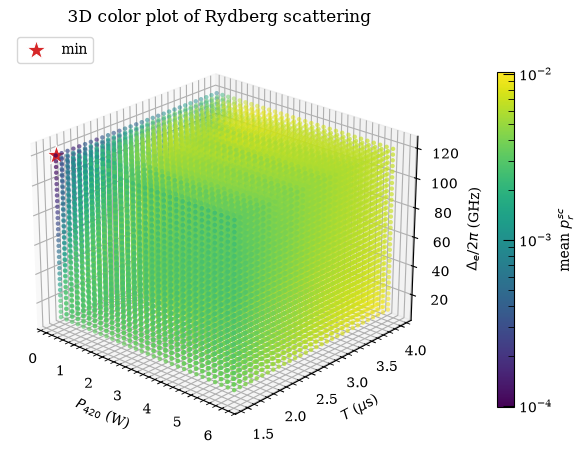

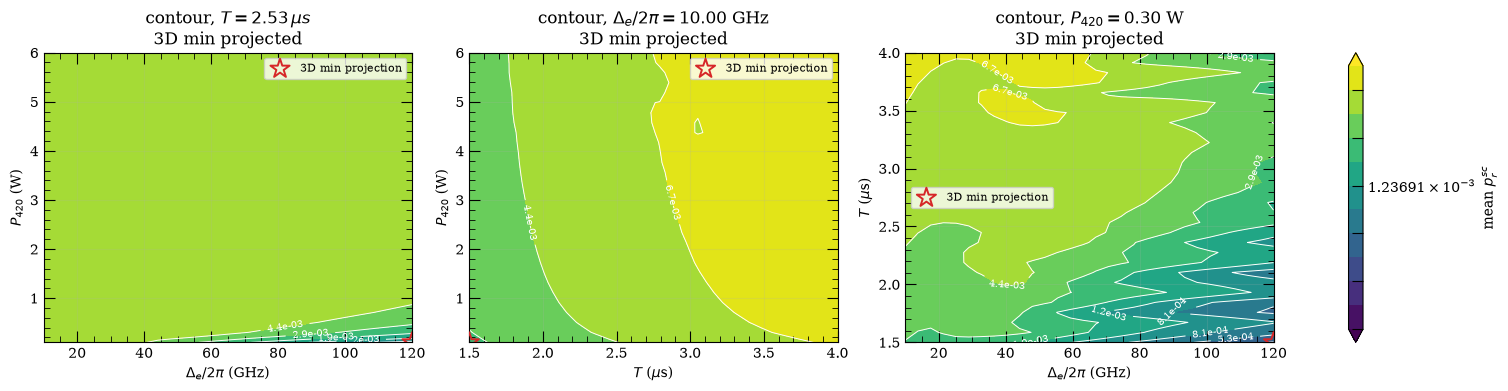

In [7]:
# Rydberg scattering: 3D color plot + contour slices.
plot_3d_and_contours(
    scan_p_ryd_mean,
    label=r"mean $p_{r}^{sc}$",
    title=r"3D color plot of Rydberg scattering",
)


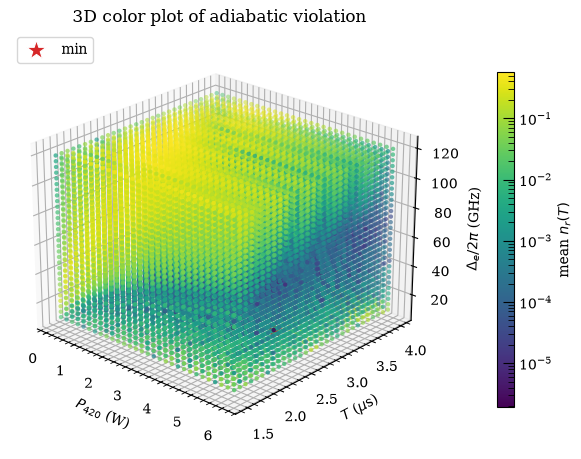

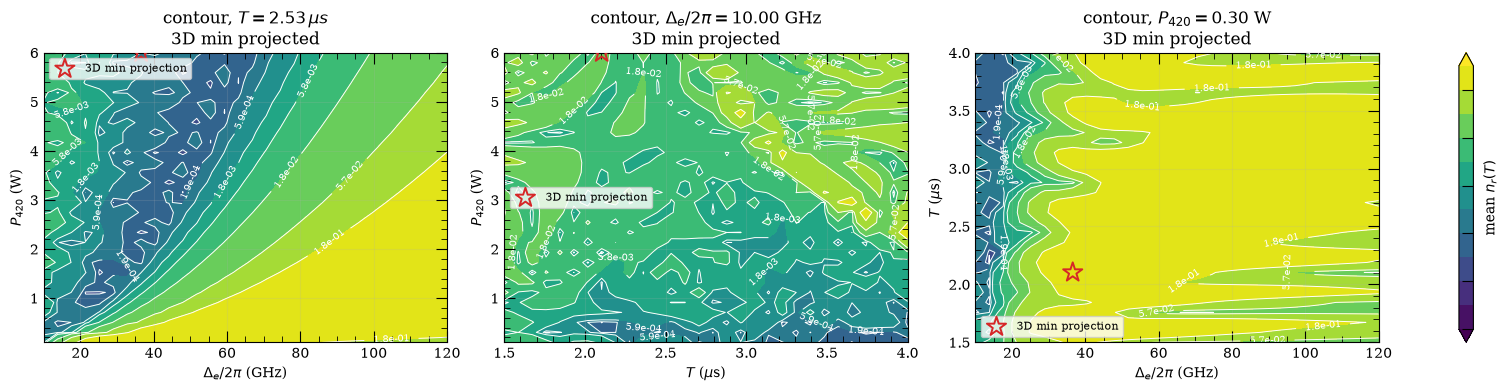

In [8]:
# Adiabatic violation: 3D color plot + contour slices.
plot_3d_and_contours(
    scan_p_ad_mean,
    label=r"mean $n_r(T)$",
    title=r"3D color plot of adiabatic violation",
)


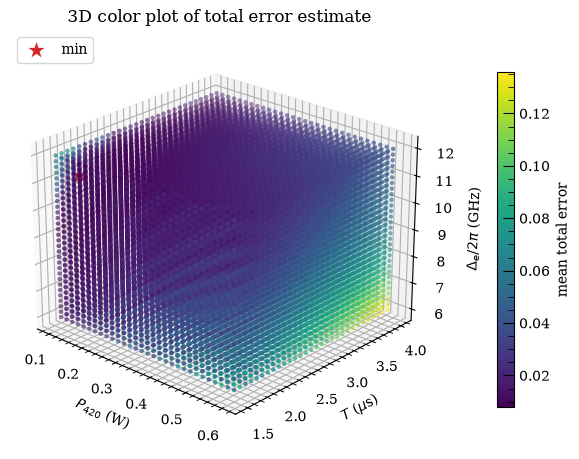

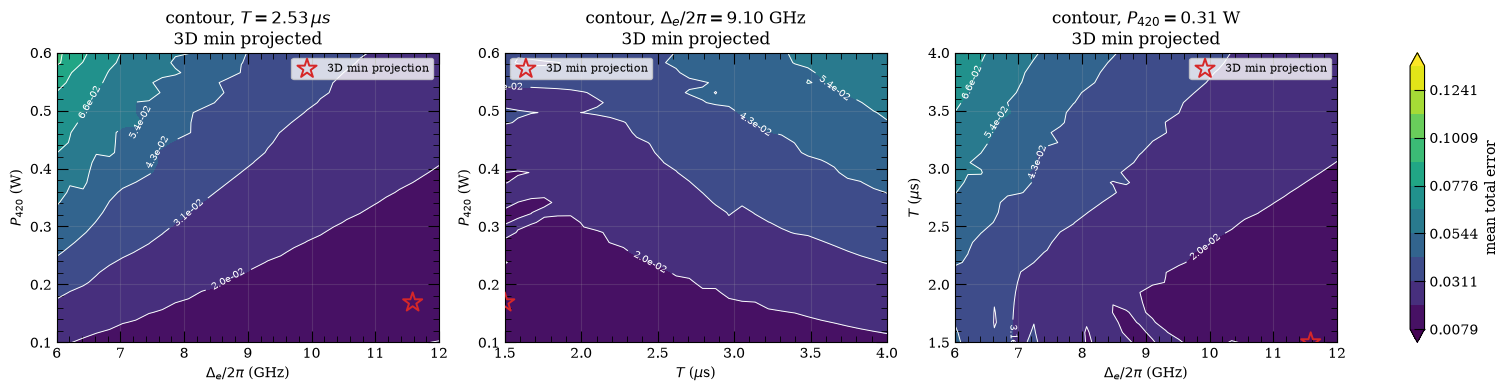

In [13]:
# Total error estimate: mid scattering + Rydberg scattering + adiabatic violation.
plot_3d_and_contours(
    scan_p_total_mean,
    label=r"mean total error",
    title=r"3D color plot of total error estimate",
)
